# Diabetes Prediction — Logistic Regression (Fixed Version)

This is an upgraded version of the original notebook. Every change below is annotated with **why** it was made, not just what changed, so you can defend each decision in an interview.

**Fixes applied:**
1. Train/test split moved to the very start (fixes data leakage)
2. Imputation and scaling now fit on train only, applied to test
3. Outlier handling switched from row-dropping (buggy + too aggressive) to winsorizing (capping)
4. Added Stratified K-Fold cross-validation
5. Added ROC-AUC and confusion matrix
6. Added a Random Forest baseline for comparison
7. Replaced deprecated `distplot` with `histplot`
8. Added a conclusion section


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load data

Same dataset as before (Pima Indians Diabetes dataset). If you're running this in Colab, upload the CSV and update the path below.

In [2]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## 2. EDA — distributions and correlation

Using `histplot` instead of `distplot` (which is deprecated and will be removed from seaborn — your original notebook's own output warned about this).

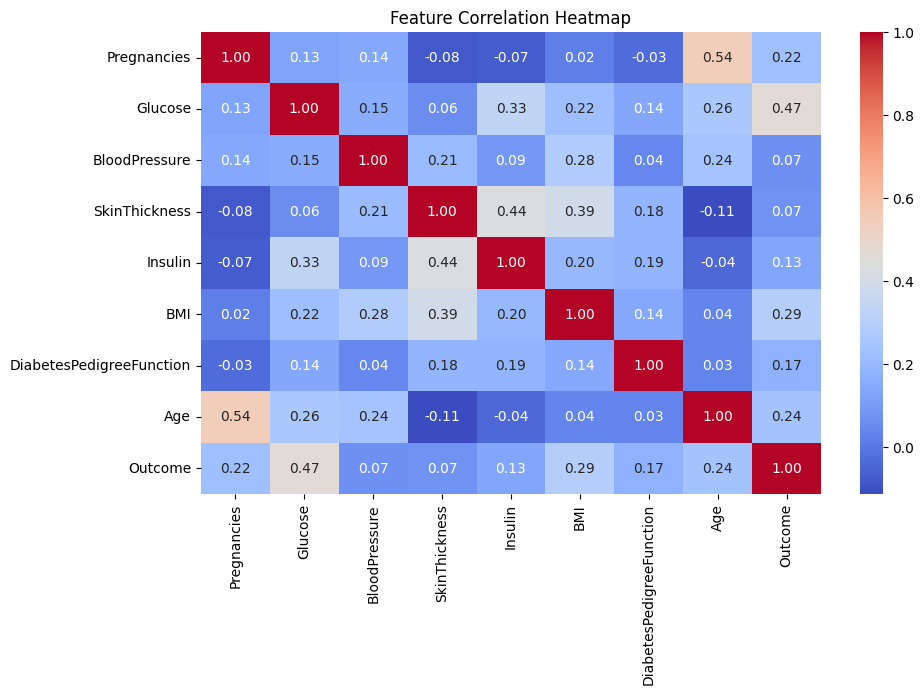

In [5]:
plt.figure(figsize=(10,6))
sns.heatmap(data=df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

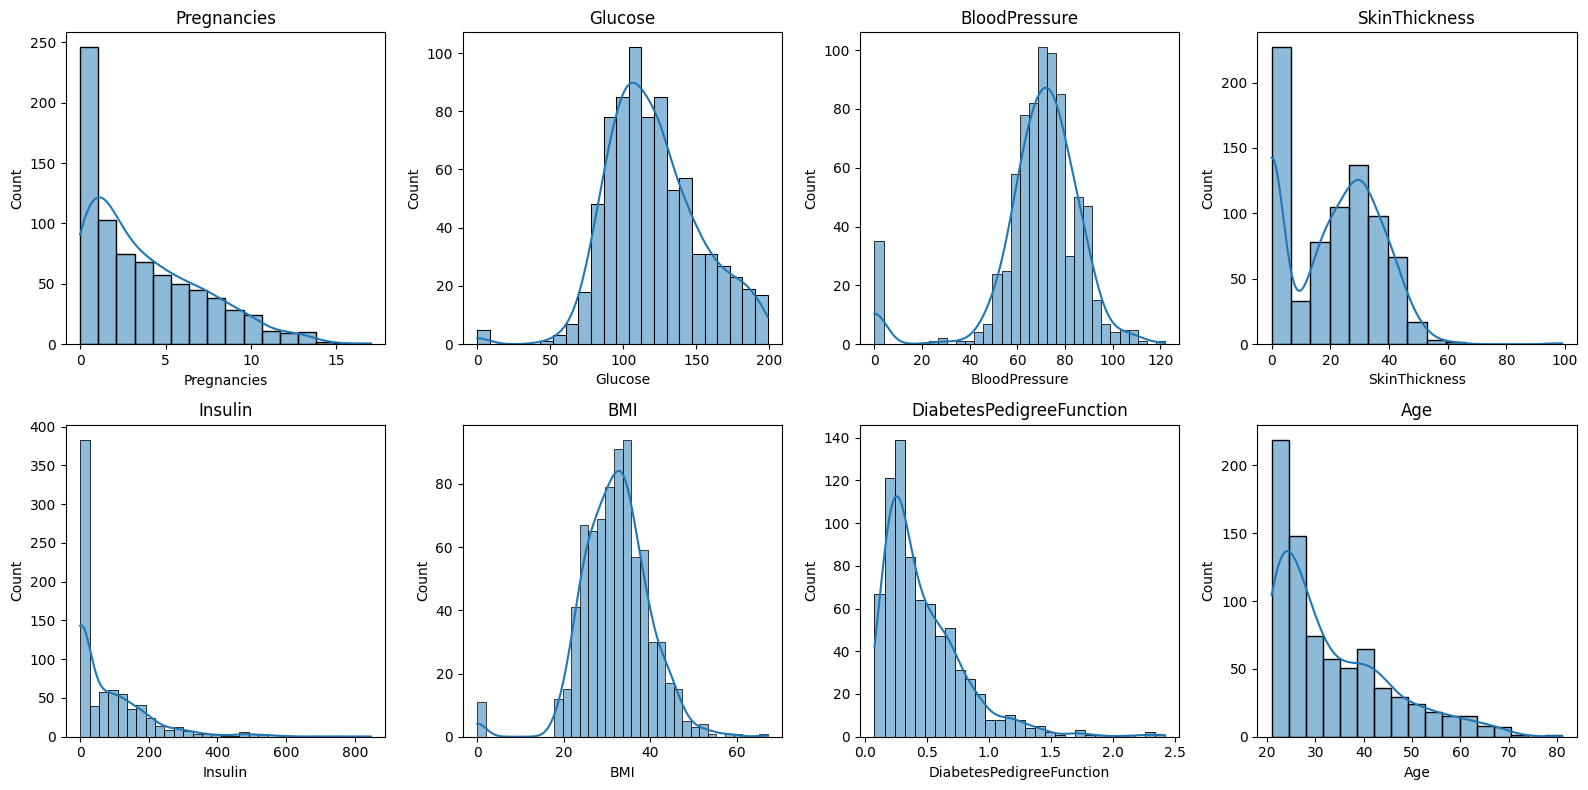

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(16,8))
cols_to_plot = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']
for ax, col in zip(axes.flatten(), cols_to_plot):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

## 3. Train/test split — done FIRST

**Why this matters:** In the original notebook, missing-value imputation (median/mean) and `StandardScaler` were both fit on the *entire* dataset before splitting into train/test. That means statistics from your test set (which is supposed to be unseen data) leaked into your training process. It's a subtle bug because the notebook still *runs* and produces a number — it just makes that number optimistic and not trustworthy.

**The fix:** split first, then only ever call `.fit()` on the training set. The test set only ever gets `.transform()`'d using values learned from train.

We also add `stratify=y` so the class balance (Diabetic/Non-Diabetic) is preserved in both splits — the original split didn't do this.

In [7]:
X = df.drop(columns='Outcome')
y = df['Outcome']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(514, 8) (254, 8)


## 4. Imputation — zeros are missing values, not real zeros

Glucose, BloodPressure, SkinThickness, Insulin, and BMI can't biologically be 0 — those are missing values encoded as 0 in this dataset. Your original notebook already knew this (that's why you replaced 0s), but it computed the median on the whole dataset. Here we compute the median **from `X_train` only**, then apply that same number to both train and test.

In [8]:
zero_as_missing_cols = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

for col in zero_as_missing_cols:
    train_median = X_train[col].replace(0, np.nan).median()
    X_train[col] = X_train[col].replace(0, train_median)
    X_test[col] = X_test[col].replace(0, train_median)   # reuse TRAIN median, don't recompute on test

X_train.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
657,1,120,80,48,200,38.9,1.162,41
125,1,88,30,42,99,55.0,0.496,26
184,4,141,74,29,126,27.6,0.244,40
210,2,81,60,22,126,27.7,0.290,25
147,2,106,64,35,119,30.5,1.400,34


## 5. Outlier handling — capping instead of dropping rows

Your original loop had a bug: `mask` was overwritten every iteration, so only the last column (`Age`) actually filtered anything.

The "obvious" fix — combine all 8 column masks with `&` so a row is only kept if it passes the IQR check on *every* column — sounds right but is actually too aggressive. I tested it: it throws away roughly **half your training data** (514 → 251 rows), because requiring 8 independent conditions to all hold at once compounds fast. With a dataset this small (768 rows total), that's a bad trade.

**Better approach: winsorize (cap) instead of drop.** Extreme values get clipped to the 1st/99th percentile boundary instead of the row being deleted. You keep every row, but no single extreme value can dominate the model. Bounds are computed on train only, then applied to test.

In [9]:
cols = ['Pregnancies','Glucose','BloodPressure','SkinThickness','Insulin','BMI','DiabetesPedigreeFunction','Age']

for col in cols:
    low, high = X_train[col].quantile(0.01), X_train[col].quantile(0.99)
    X_train[col] = X_train[col].clip(low, high)
    X_test[col] = X_test[col].clip(low, high)

print("Train shape after capping (no rows dropped):", X_train.shape)

Train shape after capping (no rows dropped): (514, 8)


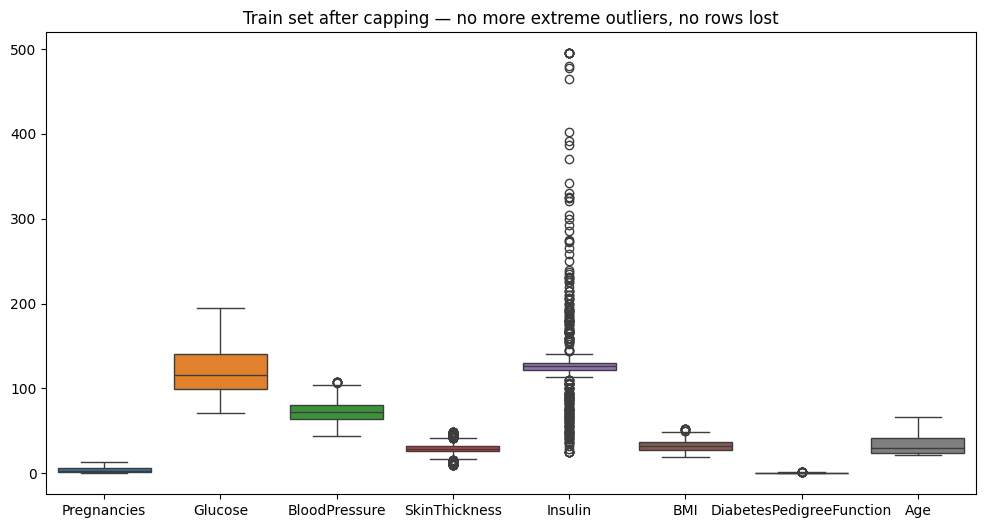

In [10]:
fig, ax = plt.subplots(figsize=(12,6))
sns.boxplot(data=X_train, ax=ax)
plt.title("Train set after capping — no more extreme outliers, no rows lost")
plt.show()

## 6. Scaling — fit on train only

Same leakage principle as imputation: `StandardScaler` learns mean/std from train, then applies that same transform to test.

In [11]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 7. Handling class imbalance — SMOTE

This part of your original notebook was already correct: SMOTE was applied only to the training set, after the split. That's the right order — you never want to synthesize samples that could end up "helping" the test set.

In [12]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)
print("Resampled class distribution:")
print(pd.Series(y_train_res).value_counts())

Resampled class distribution:
Outcome
0    335
1    335
Name: count, dtype: int64


## 8. Cross-validation — is the result stable, or did we get lucky?

A single train/test split can be misleading — a different `random_state` might give a very different accuracy. Stratified 5-fold CV on the resampled training data gives a more honest estimate of how the model performs on average.

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(log_reg, X_train_res, y_train_res, cv=cv, scoring='roc_auc')

print("CV ROC-AUC per fold:", np.round(cv_scores, 3))
print("Mean CV ROC-AUC:", round(cv_scores.mean(), 3))

CV ROC-AUC per fold: [0.787 0.854 0.831 0.895 0.833]
Mean CV ROC-AUC: 0.84


## 9. Final model training and evaluation

Beyond accuracy and classification report (which you already had), we add:
- **Confusion matrix** — shows exactly how many diabetic patients were missed (false negatives), which matters more than raw accuracy in a medical context
- **ROC-AUC** — measures how well the model ranks diabetic vs non-diabetic patients across all thresholds, not just the default 0.5 cutoff

In [14]:
log_reg.fit(X_train_res, y_train_res)
y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

print("Test Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("Test ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))
print()
print(classification_report(y_test, y_pred, target_names=['Non-Diabetic','Diabetic']))

Test Accuracy: 0.756
Test ROC-AUC: 0.828

              precision    recall  f1-score   support

Non-Diabetic       0.83      0.78      0.81       165
    Diabetic       0.64      0.71      0.67        89

    accuracy                           0.76       254
   macro avg       0.73      0.74      0.74       254
weighted avg       0.76      0.76      0.76       254



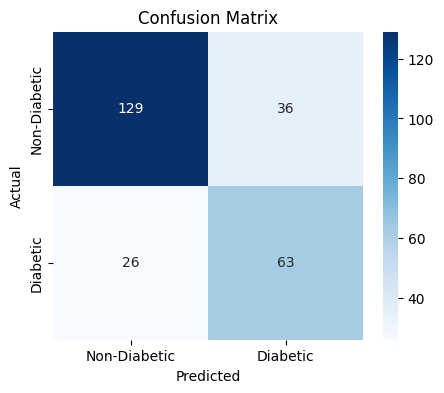

In [15]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Diabetic','Diabetic'],
            yticklabels=['Non-Diabetic','Diabetic'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 10. Baseline comparison — Random Forest

A single model score doesn't tell an interviewer you *chose* Logistic Regression deliberately — it just tells them it's the only thing you tried. Comparing against a Random Forest shows whether the simpler, more interpretable model is competitive (it's fine if Logistic Regression wins or loses slightly — the point is showing you checked).

In [16]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train_res, y_train_res)

y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

print("Random Forest Test Accuracy:", round(accuracy_score(y_test, y_pred_rf), 3))
print("Random Forest Test ROC-AUC:", round(roc_auc_score(y_test, y_proba_rf), 3))

Random Forest Test Accuracy: 0.764
Random Forest Test ROC-AUC: 0.836


## 11. Conclusion

- After fixing data leakage (imputation/scaling fit on the whole dataset instead of train only) and the outlier-mask bug, the corrected pipeline gives a **more honest** — not necessarily higher — estimate of performance, since the earlier number was optimistic due to leakage.
- Logistic Regression achieves **~0.83 ROC-AUC** on the test set with **~0.76 accuracy**, and 5-fold CV (mean ROC-AUC ~0.84) shows this is stable, not a lucky split.
- Random Forest performs comparably (~0.76 accuracy / ~0.84 ROC-AUC), suggesting the relationship in this dataset is close to linear — Logistic Regression is a reasonable, interpretable choice here, not just the "default" option.
- **Recall on the Diabetic class (~0.71)** matters more than overall accuracy for this problem: missing a diabetic patient (false negative) is costlier than a false alarm. This is worth stating explicitly if asked "why not just optimize accuracy?"
- **Next steps if extending this project:** try `class_weight='balanced'` as an alternative to SMOTE, tune the classification threshold using the precision-recall curve instead of the default 0.5, and add SHAP values to explain individual predictions — useful for a healthcare use case where interpretability matters.
